# BS Expert Mixture


1. What does one Black-Scholes calculator do?
2. Why does one constant volatility fail to recover a smile?
3. Why is a linear volatility function still limited?
4. Why does a plain MLP work but remain hard to interpret?
5. How can several Black-Scholes experts be combined with learned weights?
6. What does the expert-mixture structure add compared with a plain MLP?

Current scope: fixed-maturity synthetic implied-volatility smile recovery.


## Step 0 - Set up the experiment

I first import only the packages needed for this notebook. I also fix the random seed so that the preliminary result is reproducible.


In [1]:
from pathlib import Path
import math

import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F
from torch import nn

torch.manual_seed(11)

OUTPUT_DIR = Path('05 Experiments/outputs') if Path('05 Experiments').exists() else Path('outputs')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

MIN_IV = 0.01

print('torch version:', torch.__version__)
print('output folder:', OUTPUT_DIR.resolve())


torch version: 2.2.2
output folder: /Users/jisongli/Desktop/Dissertation/Dissertation Vault/05 Experiments/outputs


## Step 1 - Start with one Black-Scholes calculation

Before building any neural model, I want to verify one simple Black-Scholes call price.

For a European call option, the inputs are:

```text
spot price S
strike K
time to maturity T
risk-free rate r
volatility sigma
```

The output is:

```text
call option price
```

I calculate one reference case manually first, so the formula is visible.


In [2]:
S0 = torch.tensor(100.0)
K0 = torch.tensor(100.0)
T0 = torch.tensor(1.0)
r0 = torch.tensor(0.05)
sigma0 = torch.tensor(0.20)

sqrt_T0 = torch.sqrt(T0)
d1 = (torch.log(S0 / K0) + (r0 + 0.5 * sigma0**2) * T0) / (sigma0 * sqrt_T0)
d2 = d1 - sigma0 * sqrt_T0

N_d1 = 0.5 * (1.0 + torch.erf(d1 / math.sqrt(2.0)))
N_d2 = 0.5 * (1.0 + torch.erf(d2 / math.sqrt(2.0)))

call_price_0 = S0 * N_d1 - K0 * torch.exp(-r0 * T0) * N_d2

print('d1:', float(d1))
print('d2:', float(d2))
print('reference call price:', float(call_price_0))


d1: 0.3499999940395355
d2: 0.14999999105930328
reference call price: 10.45058822631836


The reference price should be close to `10.4506`. After this check, I wrap the same formula into a small reusable calculator because the rest of the notebook needs to price many strikes many times.

This helper does not change the idea; it only avoids copying the same formula repeatedly.


In [3]:
def bs_call(spot, strike, tau, rate, vol):
    strike_t = strike if isinstance(strike, torch.Tensor) else torch.tensor(strike, dtype=torch.float32)
    device = strike_t.device

    spot_t = spot.to(device=device, dtype=torch.float32) if isinstance(spot, torch.Tensor) else torch.tensor(spot, dtype=torch.float32, device=device)
    tau_t = tau.to(device=device, dtype=torch.float32) if isinstance(tau, torch.Tensor) else torch.tensor(tau, dtype=torch.float32, device=device)
    rate_t = rate.to(device=device, dtype=torch.float32) if isinstance(rate, torch.Tensor) else torch.tensor(rate, dtype=torch.float32, device=device)
    vol_t = vol.to(device=device, dtype=torch.float32) if isinstance(vol, torch.Tensor) else torch.tensor(vol, dtype=torch.float32, device=device)

    tau_safe = torch.clamp(tau_t, min=1e-6)
    vol_safe = torch.clamp(vol_t, min=1e-6)
    sqrt_tau = torch.sqrt(tau_safe)

    d1 = (torch.log(spot_t / strike_t) + (rate_t + 0.5 * vol_safe.pow(2)) * tau_safe) / (vol_safe * sqrt_tau)
    d2 = d1 - vol_safe * sqrt_tau

    cdf_d1 = 0.5 * (1.0 + torch.erf(d1 / math.sqrt(2.0)))
    cdf_d2 = 0.5 * (1.0 + torch.erf(d2 / math.sqrt(2.0)))

    return spot_t * cdf_d1 - strike_t * torch.exp(-rate_t * tau_safe) * cdf_d2

reference_price = bs_call(100.0, torch.tensor(100.0), 1.0, 0.05, 0.20)
print('calculator check:', float(reference_price))
assert torch.allclose(reference_price, torch.tensor(10.4506), atol=1e-3)


calculator check: 10.45058822631836


## Step 2 - Create synthetic smile data

Now I create a synthetic implied-volatility smile.

The model will not be trained directly on this true IV curve. Instead, I use the true IV curve to generate synthetic option prices.

This gives a clean controlled experiment:

```text
hidden true IV(K) -> Black-Scholes -> synthetic call prices
```

Then the learning model tries to recover the hidden smile from prices.


In [4]:
spot = torch.tensor(100.0)
tau = torch.tensor(0.5)
rate = torch.tensor(0.02)

strikes = torch.linspace(70.0, 130.0, 61)
log_moneyness = torch.log(strikes / spot).unsqueeze(1)

x_flat = log_moneyness.squeeze(1)
true_iv = torch.clamp(0.18 + 0.90 * x_flat.pow(2) - 0.05 * x_flat, min=MIN_IV)
target_prices = bs_call(spot, strikes, tau, rate, true_iv)

print('number of strikes:', len(strikes))
print('IV range:', float(true_iv.min()), 'to', float(true_iv.max()))
print('price range:', float(target_prices.min()), 'to', float(target_prices.max()))


number of strikes: 61
IV range: 0.17930841445922852 to 0.31232908368110657
price range: 0.4678335189819336 to 31.06499481201172


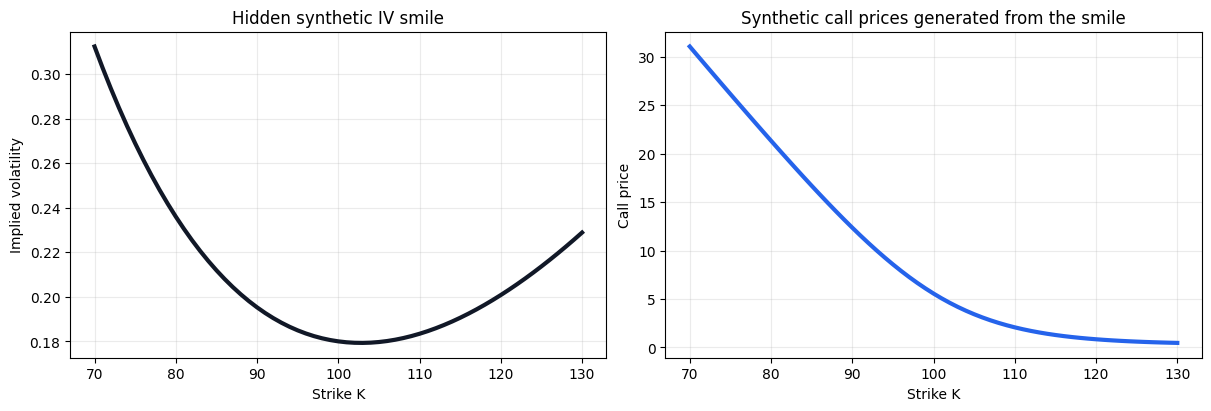

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)

axes[0].plot(strikes.numpy(), true_iv.numpy(), color='#111827', linewidth=3)
axes[0].set_title('Hidden synthetic IV smile')
axes[0].set_xlabel('Strike K')
axes[0].set_ylabel('Implied volatility')
axes[0].grid(alpha=0.25)

axes[1].plot(strikes.numpy(), target_prices.numpy(), color='#2563eb', linewidth=3)
axes[1].set_title('Synthetic call prices generated from the smile')
axes[1].set_xlabel('Strike K')
axes[1].set_ylabel('Call price')
axes[1].grid(alpha=0.25)

plt.show()


### Figure analysis - Synthetic data construction

This figure shows how the synthetic experiment is built.

- The left panel is the hidden IV smile that the model should recover.
- The right panel is the synthetic call-price curve generated by Black-Scholes.
- The call price decreases as strike increases, which is financially sensible for call options.

The key point is that the true IV smile is known, but the models are trained on option prices. This makes the experiment controlled and easy to evaluate. However, this is still synthetic data, so it does not yet prove real-market performance.


## Step 3 - Add implied-volatility inversion

Training will use price loss, but the main visual result is an IV smile.

So after a model predicts prices, I need to invert each predicted price back to implied volatility.

This helper uses bisection search. It asks: which sigma makes Black-Scholes match this call price?


In [6]:
def invert_call_to_iv(prices, low=0.01, high=0.80, iterations=80):
    lower = torch.full_like(prices, low)
    upper = torch.full_like(prices, high)

    for _ in range(iterations):
        mid = 0.5 * (lower + upper)
        mid_prices = bs_call(spot, strikes, tau, rate, mid)
        lower = torch.where(mid_prices < prices, mid, lower)
        upper = torch.where(mid_prices >= prices, mid, upper)

    return 0.5 * (lower + upper)

recovered_iv_check = invert_call_to_iv(target_prices)
max_inversion_error = torch.max(torch.abs(recovered_iv_check - true_iv))

print('max inversion error on synthetic target prices:', float(max_inversion_error))
assert max_inversion_error < 1e-5


max inversion error on synthetic target prices: 2.294778823852539e-06


## Step 4 - Baseline 1: learn one constant volatility

First I test the simplest possible learnable model.

It has only one trainable number: `sigma`.

Question:

```text
If the true IV is a smile, can one learned sigma recover it?
```

Expected answer: no. One sigma can only produce a flat IV line.


In [7]:
raw_sigma_const = nn.Parameter(torch.log(torch.expm1(torch.tensor(0.20 - MIN_IV))))
optim_const = torch.optim.Adam([raw_sigma_const], lr=0.03)
const_loss_history = []

for step in range(1000):
    optim_const.zero_grad()

    sigma_const = MIN_IV + F.softplus(raw_sigma_const)
    iv_const = sigma_const.expand_as(strikes)
    prices_const = bs_call(spot, strikes, tau, rate, iv_const)

    loss_const = torch.mean((prices_const - target_prices).pow(2))
    loss_const.backward()
    optim_const.step()

    const_loss_history.append(float(loss_const.detach()))

with torch.no_grad():
    sigma_const = MIN_IV + F.softplus(raw_sigma_const)
    iv_const = sigma_const.expand_as(strikes)
    prices_const = bs_call(spot, strikes, tau, rate, iv_const)
    const_price_error = prices_const - target_prices
    const_iv_error = iv_const - true_iv

print('learned constant sigma:', float(sigma_const))
print('constant IV MAE:', float(torch.mean(torch.abs(const_iv_error))))


learned constant sigma: 0.1874658316373825
constant IV MAE: 0.026238230988383293


Interpretation:

The constant model can learn one average volatility level, but it has no mechanism to bend into a smile. This is why it is a useful baseline but not a sufficient model.


## Step 5 - Baseline 2: learn a linear IV curve

Next I allow volatility to depend on log-moneyness:

```text
IV(K) = softplus(a * log(K/S) + b)
```

Question:

```text
Can a straight line recover a curved smile?
```

Expected answer: it may improve slightly, but it still cannot represent a U-shaped smile well.


In [8]:
linear_layer = nn.Linear(1, 1)
with torch.no_grad():
    linear_layer.weight.zero_()
    linear_layer.bias.fill_(torch.log(torch.expm1(torch.tensor(0.20 - MIN_IV))))

optim_linear = torch.optim.Adam(linear_layer.parameters(), lr=0.03)
linear_loss_history = []

for step in range(1500):
    optim_linear.zero_grad()

    iv_linear = MIN_IV + F.softplus(linear_layer(log_moneyness).squeeze(1))
    prices_linear = bs_call(spot, strikes, tau, rate, iv_linear)

    loss_linear = torch.mean((prices_linear - target_prices).pow(2))
    loss_linear.backward()
    optim_linear.step()

    linear_loss_history.append(float(loss_linear.detach()))

with torch.no_grad():
    iv_linear = MIN_IV + F.softplus(linear_layer(log_moneyness).squeeze(1))
    prices_linear = bs_call(spot, strikes, tau, rate, iv_linear)
    linear_price_error = prices_linear - target_prices
    linear_iv_error = iv_linear - true_iv

print('linear slope:', float(linear_layer.weight.squeeze()))
print('linear bias:', float(linear_layer.bias.squeeze()))
print('linear IV MAE:', float(torch.mean(torch.abs(linear_iv_error))))


linear slope: -0.16592256724834442
linear bias: -1.6347147226333618
linear IV MAE: 0.025094227865338326


## Step 6 - Baseline 3: use a plain MLP

The MLP is a flexible nonlinear benchmark.

Question:

```text
If I allow nonlinear hidden layers, can the model recover the smile?
```

Expected answer: yes, but the MLP is harder to interpret because its hidden units are not directly financial objects.


In [9]:
mlp = nn.Sequential(
    nn.Linear(1, 16),
    nn.Tanh(),
    nn.Linear(16, 16),
    nn.Tanh(),
    nn.Linear(16, 1),
)

with torch.no_grad():
    mlp[-1].weight.zero_()
    mlp[-1].bias.fill_(torch.log(torch.expm1(torch.tensor(0.20 - MIN_IV))))

optim_mlp = torch.optim.Adam(mlp.parameters(), lr=0.03)
mlp_loss_history = []

for step in range(3000):
    optim_mlp.zero_grad()

    iv_mlp = MIN_IV + F.softplus(mlp(log_moneyness).squeeze(1))
    prices_mlp = bs_call(spot, strikes, tau, rate, iv_mlp)

    loss_mlp = torch.mean((prices_mlp - target_prices).pow(2))
    loss_mlp.backward()
    optim_mlp.step()

    mlp_loss_history.append(float(loss_mlp.detach()))

with torch.no_grad():
    iv_mlp = MIN_IV + F.softplus(mlp(log_moneyness).squeeze(1))
    prices_mlp = bs_call(spot, strikes, tau, rate, iv_mlp)
    mlp_price_error = prices_mlp - target_prices
    mlp_iv_error = iv_mlp - true_iv

print('MLP IV MAE:', float(torch.mean(torch.abs(mlp_iv_error))))


MLP IV MAE: 0.0003511544200591743


Interpretation:

The MLP is useful as a benchmark because it tests whether nonlinear learning can recover the synthetic smile. However, if it works, it does not immediately explain which financial mechanism is being used.

This motivates the BS expert-mixture idea.


## Step 7 - What is a Black-Scholes expert?


One BS expert means one full Black-Scholes pricing curve across all strikes, using one volatility level.

For example, four experts with different sigmas produce four different price curves.


In [10]:
expert_sigmas_fixed = torch.tensor([0.12, 0.18, 0.24, 0.32])

expert_prices_fixed = bs_call(
    spot,
    strikes.unsqueeze(1),
    tau,
    rate,
    expert_sigmas_fixed.unsqueeze(0),
)

print('expert_prices shape:', tuple(expert_prices_fixed.shape))
print('meaning: rows = strikes, columns = BS experts')


expert_prices shape: (61, 4)
meaning: rows = strikes, columns = BS experts


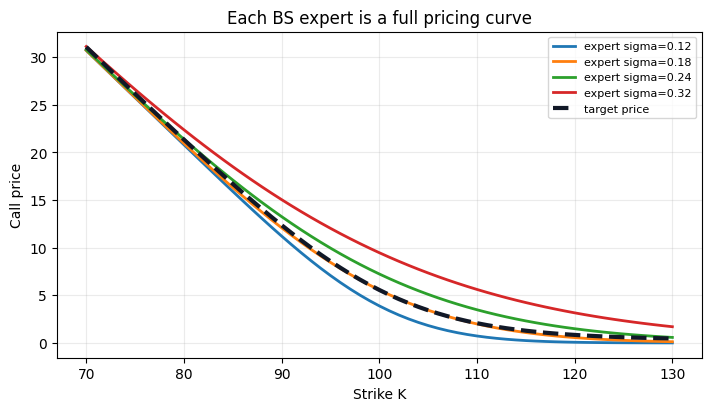

In [11]:
fig, ax = plt.subplots(figsize=(7, 4), constrained_layout=True)

for idx, sigma_value in enumerate(expert_sigmas_fixed):
    ax.plot(strikes.numpy(), expert_prices_fixed[:, idx].detach().numpy(), linewidth=2, label=f'expert sigma={float(sigma_value):.2f}')

ax.plot(strikes.numpy(), target_prices.detach().numpy(), color='#111827', linewidth=3, linestyle='--', label='target price')
ax.set_title('Each BS expert is a full pricing curve')
ax.set_xlabel('Strike K')
ax.set_ylabel('Call price')
ax.legend(fontsize=8)
ax.grid(alpha=0.25)
plt.show()


### Figure analysis - What one BS expert represents

This figure clarifies that one BS expert is a full pricing curve, not a single point.

Each expert uses a different volatility level and produces option prices across all strikes. Higher-volatility experts generally produce higher option prices.

This matters because the expert-mixture model combines several BS pricing curves using learned strike-dependent weights. This gives the model more financial structure than a plain MLP.


## Step 8 - Fixed BS expert mixture

Now I keep the expert sigmas fixed, but learn how to combine them.

The gating network receives log-moneyness and outputs weights:

```text
log(K/S) -> gating network -> weights over BS experts
```

The final price is:

```text
mixed price = weighted average of expert prices
```

Question:

```text
Can learned strike-dependent weights combine simple BS calculators into a smile-like pricing structure?
```


In [12]:
gate_fixed = nn.Sequential(
    nn.Linear(1, 16),
    nn.Tanh(),
    nn.Linear(16, len(expert_sigmas_fixed)),
)

optim_fixed = torch.optim.Adam(gate_fixed.parameters(), lr=0.03)
fixed_loss_history = []

for step in range(3000):
    optim_fixed.zero_grad()

    weights_fixed = F.softmax(gate_fixed(log_moneyness), dim=1)
    prices_fixed_mix = torch.sum(weights_fixed * expert_prices_fixed, dim=1)

    loss_fixed = torch.mean((prices_fixed_mix - target_prices).pow(2))
    loss_fixed.backward()
    optim_fixed.step()

    fixed_loss_history.append(float(loss_fixed.detach()))

with torch.no_grad():
    weights_fixed = F.softmax(gate_fixed(log_moneyness), dim=1)
    prices_fixed_mix = torch.sum(weights_fixed * expert_prices_fixed, dim=1)
    iv_fixed_mix = invert_call_to_iv(prices_fixed_mix)
    fixed_mix_price_error = prices_fixed_mix - target_prices
    fixed_mix_iv_error = iv_fixed_mix - true_iv

print('fixed expert mixture IV MAE:', float(torch.mean(torch.abs(fixed_mix_iv_error))))
print('minimum expert weight:', float(weights_fixed.min()))
print('max |sum(weights)-1|:', float(torch.max(torch.abs(weights_fixed.sum(dim=1) - 1.0))))


fixed expert mixture IV MAE: 0.0005044688005000353
minimum expert weight: 0.0018624766962602735
max |sum(weights)-1|: 1.1920928955078125e-07


Interpretation:

The weights are useful because they are inspectable. They show which BS calculators the model uses in different strike regions.

This is the main interpretability advantage over a plain MLP.


## Step 9 - Trainable-sigma BS expert mixture

The fixed expert mixture depends on manually chosen expert sigmas.

So I now let the model learn the expert volatility levels as well as the gating weights.

Question:

```text
Can the model learn both the BS expert sigmas and the strike-dependent mixture weights?
```


In [13]:
initial_sigmas = torch.tensor([0.12, 0.18, 0.24, 0.32])
raw_expert_sigmas = nn.Parameter(torch.log(torch.expm1(initial_sigmas - MIN_IV)))

gate_trainable = nn.Sequential(
    nn.Linear(1, 16),
    nn.Tanh(),
    nn.Linear(16, len(initial_sigmas)),
)

optim_trainable = torch.optim.Adam([raw_expert_sigmas] + list(gate_trainable.parameters()), lr=0.03)
trainable_loss_history = []

for step in range(3000):
    optim_trainable.zero_grad()

    learned_sigmas = MIN_IV + F.softplus(raw_expert_sigmas)
    expert_prices_trainable = bs_call(
        spot,
        strikes.unsqueeze(1),
        tau,
        rate,
        learned_sigmas.unsqueeze(0),
    )
    weights_trainable = F.softmax(gate_trainable(log_moneyness), dim=1)
    prices_trainable_mix = torch.sum(weights_trainable * expert_prices_trainable, dim=1)

    loss_trainable = torch.mean((prices_trainable_mix - target_prices).pow(2))
    loss_trainable.backward()
    optim_trainable.step()

    trainable_loss_history.append(float(loss_trainable.detach()))

with torch.no_grad():
    learned_sigmas = MIN_IV + F.softplus(raw_expert_sigmas)
    expert_prices_trainable = bs_call(
        spot,
        strikes.unsqueeze(1),
        tau,
        rate,
        learned_sigmas.unsqueeze(0),
    )
    weights_trainable = F.softmax(gate_trainable(log_moneyness), dim=1)
    prices_trainable_mix = torch.sum(weights_trainable * expert_prices_trainable, dim=1)
    iv_trainable_mix = invert_call_to_iv(prices_trainable_mix)
    trainable_mix_price_error = prices_trainable_mix - target_prices
    trainable_mix_iv_error = iv_trainable_mix - true_iv

print('learned expert sigmas:', [round(float(v), 6) for v in learned_sigmas])
print('trainable expert mixture IV MAE:', float(torch.mean(torch.abs(trainable_mix_iv_error))))
print('minimum expert weight:', float(weights_trainable.min()))
print('max |sum(weights)-1|:', float(torch.max(torch.abs(weights_trainable.sum(dim=1) - 1.0))))


learned expert sigmas: [0.114475, 0.186303, 0.215823, 0.547482]
trainable expert mixture IV MAE: 0.00015068688662722707
minimum expert weight: 0.04451915621757507
max |sum(weights)-1|: 1.7881393432617188e-07


## Step 10 - Compare all models

Now I compare all models using both price-level and IV-level metrics.

The important point is that the model is trained on price error, but the project interpretation also needs IV recovery error.


In [14]:
model_outputs = {
    'Constant IV': (prices_const, iv_const, const_loss_history),
    'Linear IV': (prices_linear, iv_linear, linear_loss_history),
    'MLP IV': (prices_mlp, iv_mlp, mlp_loss_history),
    'Fixed BS Experts': (prices_fixed_mix, iv_fixed_mix, fixed_loss_history),
    'Trainable BS Experts': (prices_trainable_mix, iv_trainable_mix, trainable_loss_history),
}

metrics = {}
for name, (price_curve, iv_curve, _) in model_outputs.items():
    price_error = price_curve - target_prices
    iv_error = iv_curve - true_iv
    metrics[name] = {
        'price_mse': float(torch.mean(price_error.pow(2))),
        'price_mae': float(torch.mean(torch.abs(price_error))),
        'iv_mae': float(torch.mean(torch.abs(iv_error))),
        'iv_max_error': float(torch.max(torch.abs(iv_error))),
    }

print(f"{'Model':<22} {'Price MSE':>12} {'Price MAE':>12} {'IV MAE':>12} {'Max IV Err':>12}")
print('-' * 78)
for name, values in metrics.items():
    print(f"{name:<22} {values['price_mse']:>12.8f} {values['price_mae']:>12.8f} {values['iv_mae']:>12.8f} {values['iv_max_error']:>12.8f}")


Model                     Price MSE    Price MAE       IV MAE   Max IV Err
------------------------------------------------------------------------------
Constant IV              0.05835045   0.21543266   0.02623823   0.12486325
Linear IV                0.05713267   0.21498233   0.02509423   0.11427650
MLP IV                   0.00002695   0.00426467   0.00035115   0.00220260
Fixed BS Experts         0.00005990   0.00481257   0.00050447   0.00758943
Trainable BS Experts     0.00000441   0.00165880   0.00015069   0.00131258


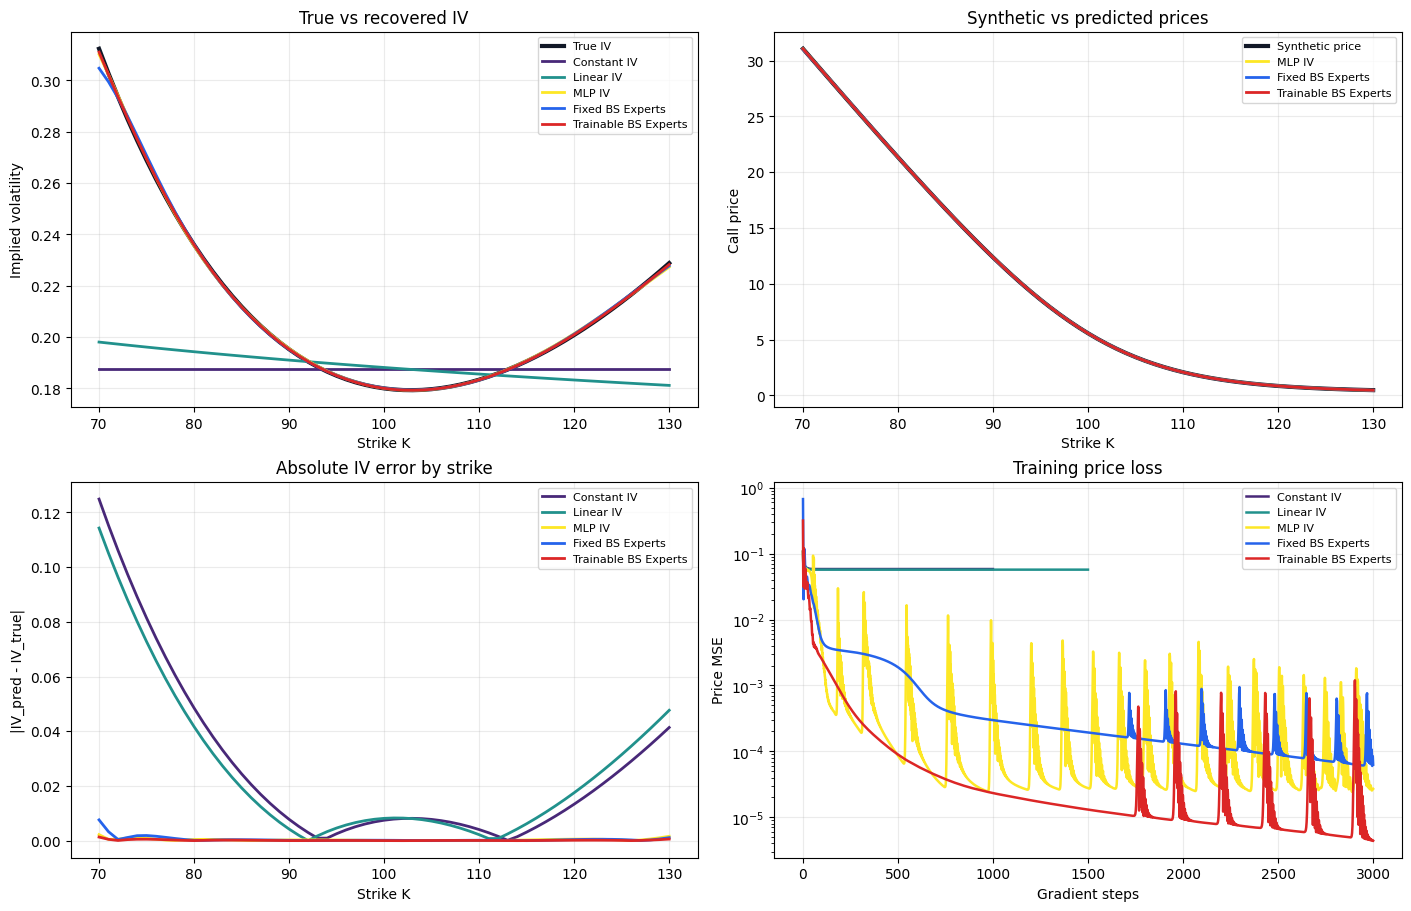

saved: outputs/bs_expert_thinking_process_diagnostics.png


In [15]:
colors = {
    'True IV': '#111827',
    'Constant IV': '#482878',
    'Linear IV': '#21918c',
    'MLP IV': '#fde725',
    'Fixed BS Experts': '#2563eb',
    'Trainable BS Experts': '#dc2626',
}

fig, axes = plt.subplots(2, 2, figsize=(14, 9), constrained_layout=True)

axes[0, 0].plot(strikes.numpy(), true_iv.numpy(), color=colors['True IV'], linewidth=3, label='True IV')
for name, (_, iv_curve, _) in model_outputs.items():
    axes[0, 0].plot(strikes.numpy(), iv_curve.detach().numpy(), linewidth=2, label=name, color=colors[name])
axes[0, 0].set_title('True vs recovered IV')
axes[0, 0].set_xlabel('Strike K')
axes[0, 0].set_ylabel('Implied volatility')
axes[0, 0].legend(fontsize=8)
axes[0, 0].grid(alpha=0.25)

axes[0, 1].plot(strikes.numpy(), target_prices.detach().numpy(), color=colors['True IV'], linewidth=3, label='Synthetic price')
for name in ['MLP IV', 'Fixed BS Experts', 'Trainable BS Experts']:
    price_curve, _, _ = model_outputs[name]
    axes[0, 1].plot(strikes.numpy(), price_curve.detach().numpy(), linewidth=2, label=name, color=colors[name])
axes[0, 1].set_title('Synthetic vs predicted prices')
axes[0, 1].set_xlabel('Strike K')
axes[0, 1].set_ylabel('Call price')
axes[0, 1].legend(fontsize=8)
axes[0, 1].grid(alpha=0.25)

for name, (_, iv_curve, _) in model_outputs.items():
    err = torch.abs(iv_curve - true_iv).detach().numpy()
    axes[1, 0].plot(strikes.numpy(), err, linewidth=2, label=name, color=colors[name])
axes[1, 0].set_title('Absolute IV error by strike')
axes[1, 0].set_xlabel('Strike K')
axes[1, 0].set_ylabel('|IV_pred - IV_true|')
axes[1, 0].legend(fontsize=8)
axes[1, 0].grid(alpha=0.25)

for name, (_, _, history) in model_outputs.items():
    axes[1, 1].plot(history, linewidth=1.8, label=name, color=colors[name])
axes[1, 1].set_title('Training price loss')
axes[1, 1].set_xlabel('Gradient steps')
axes[1, 1].set_ylabel('Price MSE')
axes[1, 1].set_yscale('log')
axes[1, 1].legend(fontsize=8)
axes[1, 1].grid(alpha=0.25)

path = OUTPUT_DIR / 'bs_expert_thinking_process_diagnostics.png'
fig.savefig(path, dpi=180)
plt.show()
print('saved:', path)


### Figure analysis - Model comparison diagnostics

This is the main comparison figure.

- Constant IV and Linear IV are too restrictive, so they cannot recover the smile well.
- The MLP and BS expert-mixture models fit the synthetic smile much better.
- The IV-error plot shows that the simple baselines struggle most where the smile bends.
- The training-loss plot shows that nonlinear models reduce price loss by several orders of magnitude.

The spikes in the training-loss plot are likely caused by an aggressive learning rate and, for the trainable expert model, interaction between learned sigmas and gating weights. The log-scale y-axis also makes late-stage spikes look visually large.

The cautious conclusion is: the BS expert mixture works well in this controlled synthetic setting, but multi-seed tests and train/test strike splits are still needed.


## Step 11 - Inspect the expert weights

This is the part that makes the BS expert-mixture model easier to explain than a plain MLP.

The MLP only gives a final curve. The expert-mixture model also gives:

```text
which BS expert is used more at each strike
```

This does not make the model fully transparent, because the gating network is still learned. But it gives a more interpretable diagnostic than hidden-layer activations in a plain MLP.


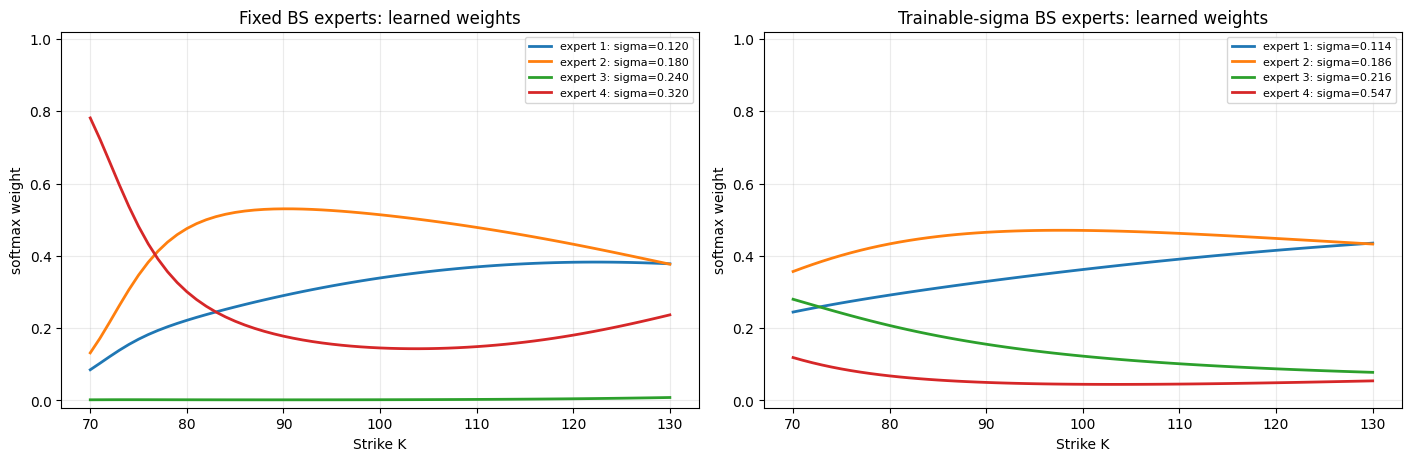

saved: outputs/bs_expert_thinking_process_weights.png


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5), constrained_layout=True)

for idx in range(weights_fixed.shape[1]):
    axes[0].plot(
        strikes.numpy(),
        weights_fixed[:, idx].detach().numpy(),
        linewidth=2,
        label=f'expert {idx + 1}: sigma={float(expert_sigmas_fixed[idx]):.3f}',
    )
axes[0].set_title('Fixed BS experts: learned weights')
axes[0].set_xlabel('Strike K')
axes[0].set_ylabel('softmax weight')
axes[0].set_ylim(-0.02, 1.02)
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.25)

for idx in range(weights_trainable.shape[1]):
    axes[1].plot(
        strikes.numpy(),
        weights_trainable[:, idx].detach().numpy(),
        linewidth=2,
        label=f'expert {idx + 1}: sigma={float(learned_sigmas[idx]):.3f}',
    )
axes[1].set_title('Trainable-sigma BS experts: learned weights')
axes[1].set_xlabel('Strike K')
axes[1].set_ylabel('softmax weight')
axes[1].set_ylim(-0.02, 1.02)
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.25)

path = OUTPUT_DIR / 'bs_expert_thinking_process_weights.png'
fig.savefig(path, dpi=180)
plt.show()
print('saved:', path)


### Figure analysis - Expert weights and interpretability

This figure is the main interpretability diagnostic.

The lines show how much weight the model gives to each BS expert at each strike. Because the weights change across strike, the model is using different volatility experts in different regions of the smile.

This makes the BS expert-mixture model more interpretable than a plain MLP: the final price can be linked back to BS expert prices and their learned weights. It is still not fully transparent, because the gating network is learned by a neural network.


## Step 12 - Current interpretation

From this preliminary single-seed experiment:

- The constant IV model learns only one volatility level, so it produces a flat IV curve.
- The linear IV model is still too restrictive for a curved smile.
- The MLP can recover the synthetic smile, but it is mostly a black-box nonlinear benchmark.
- The BS expert mixture uses several Black-Scholes pricing curves and learns strike-dependent weights.
- The trainable-sigma expert mixture also learns the expert volatility levels, reducing the need to choose them manually.

Important limitation:

These results are not final evidence yet. The next required step is multi-seed evaluation and a train/test strike split.

Uncertainty/disagreement:

Multi-seed ensemble disagreement is planned as a robustness and uncertainty diagnostic. This does not need to be asked as an open question.

Pooling question for supervisor:

Pooling is probably not necessary for the current one-dimensional fixed-maturity K-IV smile recovery problem. It may become relevant only if the project expands to a two-dimensional K-T implied-volatility surface. 
